In [1]:
import os, json
from dotenv import load_dotenv

import textwrap

import truststore
truststore.inject_into_ssl()

def pretty_print(*args):
    text = " ".join(str(arg) for arg in args)
    try:
        print(textwrap.fill(text, width=80))
    except Exception as e:
        print(text)  # fallback to normal print if text is not a string

        

load_dotenv('/Users/shivam13juna/Documents/scaler/GEN_AI_REF/openai_key.env')  # reads .env file in the current directory

api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    raise ValueError(
        "OPENAI_API_KEY not found! "
        "Make sure you have a .env file with: OPENAI_API_KEY=sk-..."
    )

pretty_print("API key loaded successfully.")

API key loaded successfully.


In [3]:
from openai import OpenAI
client = OpenAI(api_key=api_key)
pretty_print("OpenAI client ready.")


MODEL = 'gpt-5-nano'


OpenAI client ready.


In [4]:
import nest_asyncio
nest_asyncio.apply()   # Lets us use asyncio.run() inside Jupyter

import os
import json
import asyncio
import httpx
from openai import OpenAI
from pprint import pprint


def get_weather_manual(latitude: float, longitude: float) -> dict:
    """Call the Open-Meteo API to get current weather for given coordinates."""
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "current_weather": True
    }
    response = httpx.get(url, params=params)
    response.raise_for_status()
    data = response.json()
    weather = data["current_weather"]
    return {
        "temperature_celsius": weather["temperature"],
        "windspeed_kmh": weather["windspeed"],
        "weather_code": weather["weathercode"],
        "is_day": weather["is_day"] == 1
    }

# Quick test
result = get_weather_manual(48.8566, 2.3522)  # Paris
print("Direct API call result for Paris:")
pprint(result)

Direct API call result for Paris:
{'is_day': True,
 'temperature_celsius': 31.9,
 'weather_code': 1,
 'windspeed_kmh': 13.7}


In [5]:
weather_tool_schema = {
    "type": "function",
    "function": {
        "name": "get_weather",
        "description": "Get the current weather for a location given its latitude and longitude. "
                       "Returns temperature in Celsius, wind speed, and weather conditions.",
        "parameters": {
            "type": "object",
            "properties": {
                "latitude": {
                    "type": "number",
                    "description": "Latitude of the location (e.g., 48.8566 for Paris)"
                },
                "longitude": {
                    "type": "number",
                    "description": "Longitude of the location (e.g., 2.3522 for Paris)"
                }
            },
            "required": ["latitude", "longitude"]
        }
    }
}

In [6]:

def chat_with_weather_tool(user_message: str) -> str:
    """
    A complete manual tool-use loop:
    1. Send user message + tool definitions to the LLM
    2. If the LLM wants to call a tool, parse the request
    3. Execute the function locally
    4. Send the result back to the LLM
    5. Return the final answer
    """

    messages = [
        {"role": "system", "content": "You are a helpful assistant. Use the get_weather tool when asked about weather."},
        {"role": "user", "content": user_message}
    ]

    # ── First LLM call: may return a tool_call ──
    response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        tools=[weather_tool_schema],
        tool_choice="auto"
    )

    assistant_msg = response.choices[0].message

    # ── Check if the LLM wants to use a tool ──
    if assistant_msg.tool_calls:
        for tool_call in assistant_msg.tool_calls:
            function_name = tool_call.function.name
            arguments = json.loads(tool_call.function.arguments)

            print(f"🔧 LLM requested tool: {function_name}")
            print(f"   Arguments: {arguments}")

            # ── Route to the correct function ──
            # With N tools, this becomes a massive if/elif block!
            if function_name == "get_weather":
                tool_result = get_weather_manual(
                    latitude=arguments["latitude"],
                    longitude=arguments["longitude"]
                )
            else:
                tool_result = {"error": f"Unknown tool: {function_name}"}

            print(f"   Result: {tool_result}")

            # ── Send tool result back to LLM ──
            messages.append(assistant_msg)
            messages.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "content": json.dumps(tool_result)
            })

        # ── Second LLM call: now with the tool result ──
        response = client.chat.completions.create(
            model=MODEL,
            messages=messages,
        )
        return response.choices[0].message.content

    else:
        return assistant_msg.content

# Let's test it!
answer = chat_with_weather_tool("What's the weather like in Tokyo right now?")
print("\n" + "="*60)
print("💬 Final Answer:")
print(answer)

🔧 LLM requested tool: get_weather
   Arguments: {'latitude': 35.6762, 'longitude': 139.6503}
   Result: {'temperature_celsius': 22.5, 'windspeed_kmh': 3.1, 'weather_code': 2, 'is_day': False}

💬 Final Answer:
Right now in Tokyo:
- Temperature: 22.5°C
- Wind: 3.1 km/h (light)
- Conditions: it's nighttime

Would you like a forecast or the temperature in Fahrenheit?


Suppose your AI app wants to support:

* weather
* calendar
* Gmail
* GitHub
* Slack
* filesystem
* database queries
* PDF retrieval
* ticketing systems
* internal company tools

In [ ]:
# ── OpenAI ──
openai_tool = {
    "type": "function",
    "function": {
        "name": "get_weather",
        "description": "Get current weather",
        "parameters": {
            "type": "object",
            "properties": {
                "latitude":  {"type": "number"},
                "longitude": {"type": "number"},
            },
            "required": ["latitude", "longitude"],
        },
    },
}

# ── Anthropic ──  (flatter, "input_schema" not "parameters")
anthropic_tool = {
    "name": "get_weather",
    "description": "Get current weather",
    "input_schema": {
        "type": "object",
        "properties": {
            "latitude":  {"type": "number"},
            "longitude": {"type": "number"},
        },
        "required": ["latitude", "longitude"],
    },
}

# ── Google Gemini ──  (wrapped in "function_declarations")
gemini_tool = {
    "function_declarations": [{
        "name": "get_weather",
        "description": "Get current weather",
        "parameters": {
            "type": "object",
            "properties": {
                "latitude":  {"type": "number"},
                "longitude": {"type": "number"},
            },
            "required": ["latitude", "longitude"],
        },
    }],
}


If I add 10 tools, I need to first create 10 tool definition, then need to 3 schema for each tool

10 * 3 = 30 integrations

# Two most important functions in MCP

1. list-tools
2. call-tools



First, discover tools:

```json
{
  "jsonrpc": "2.0",
  "id": 1,
  "method": "tools/list"
}
```

Simplified response:

```json
{
  "jsonrpc": "2.0",
  "id": 1,
  "result": {
    "tools": [
      {
        "name": "get_weather",
        "description": "Get the current weather for a given city.",
        "inputSchema": {
          "type": "object",
          "properties": {
            "city": { "type": "string" }
          },
          "required": ["city"]
        }
      }
    ]
  }
}
```

Then call the tool:

```json
{
  "jsonrpc": "2.0",
  "id": 2,
  "method": "tools/call",
  "params": {
    "name": "get_weather",
    "arguments": {
      "city": "Delhi"
    }
  }
}

I have three bananas, two apples, five oranges, and six pineapples. How many fruits do I have?

add(3,2, 5,6)

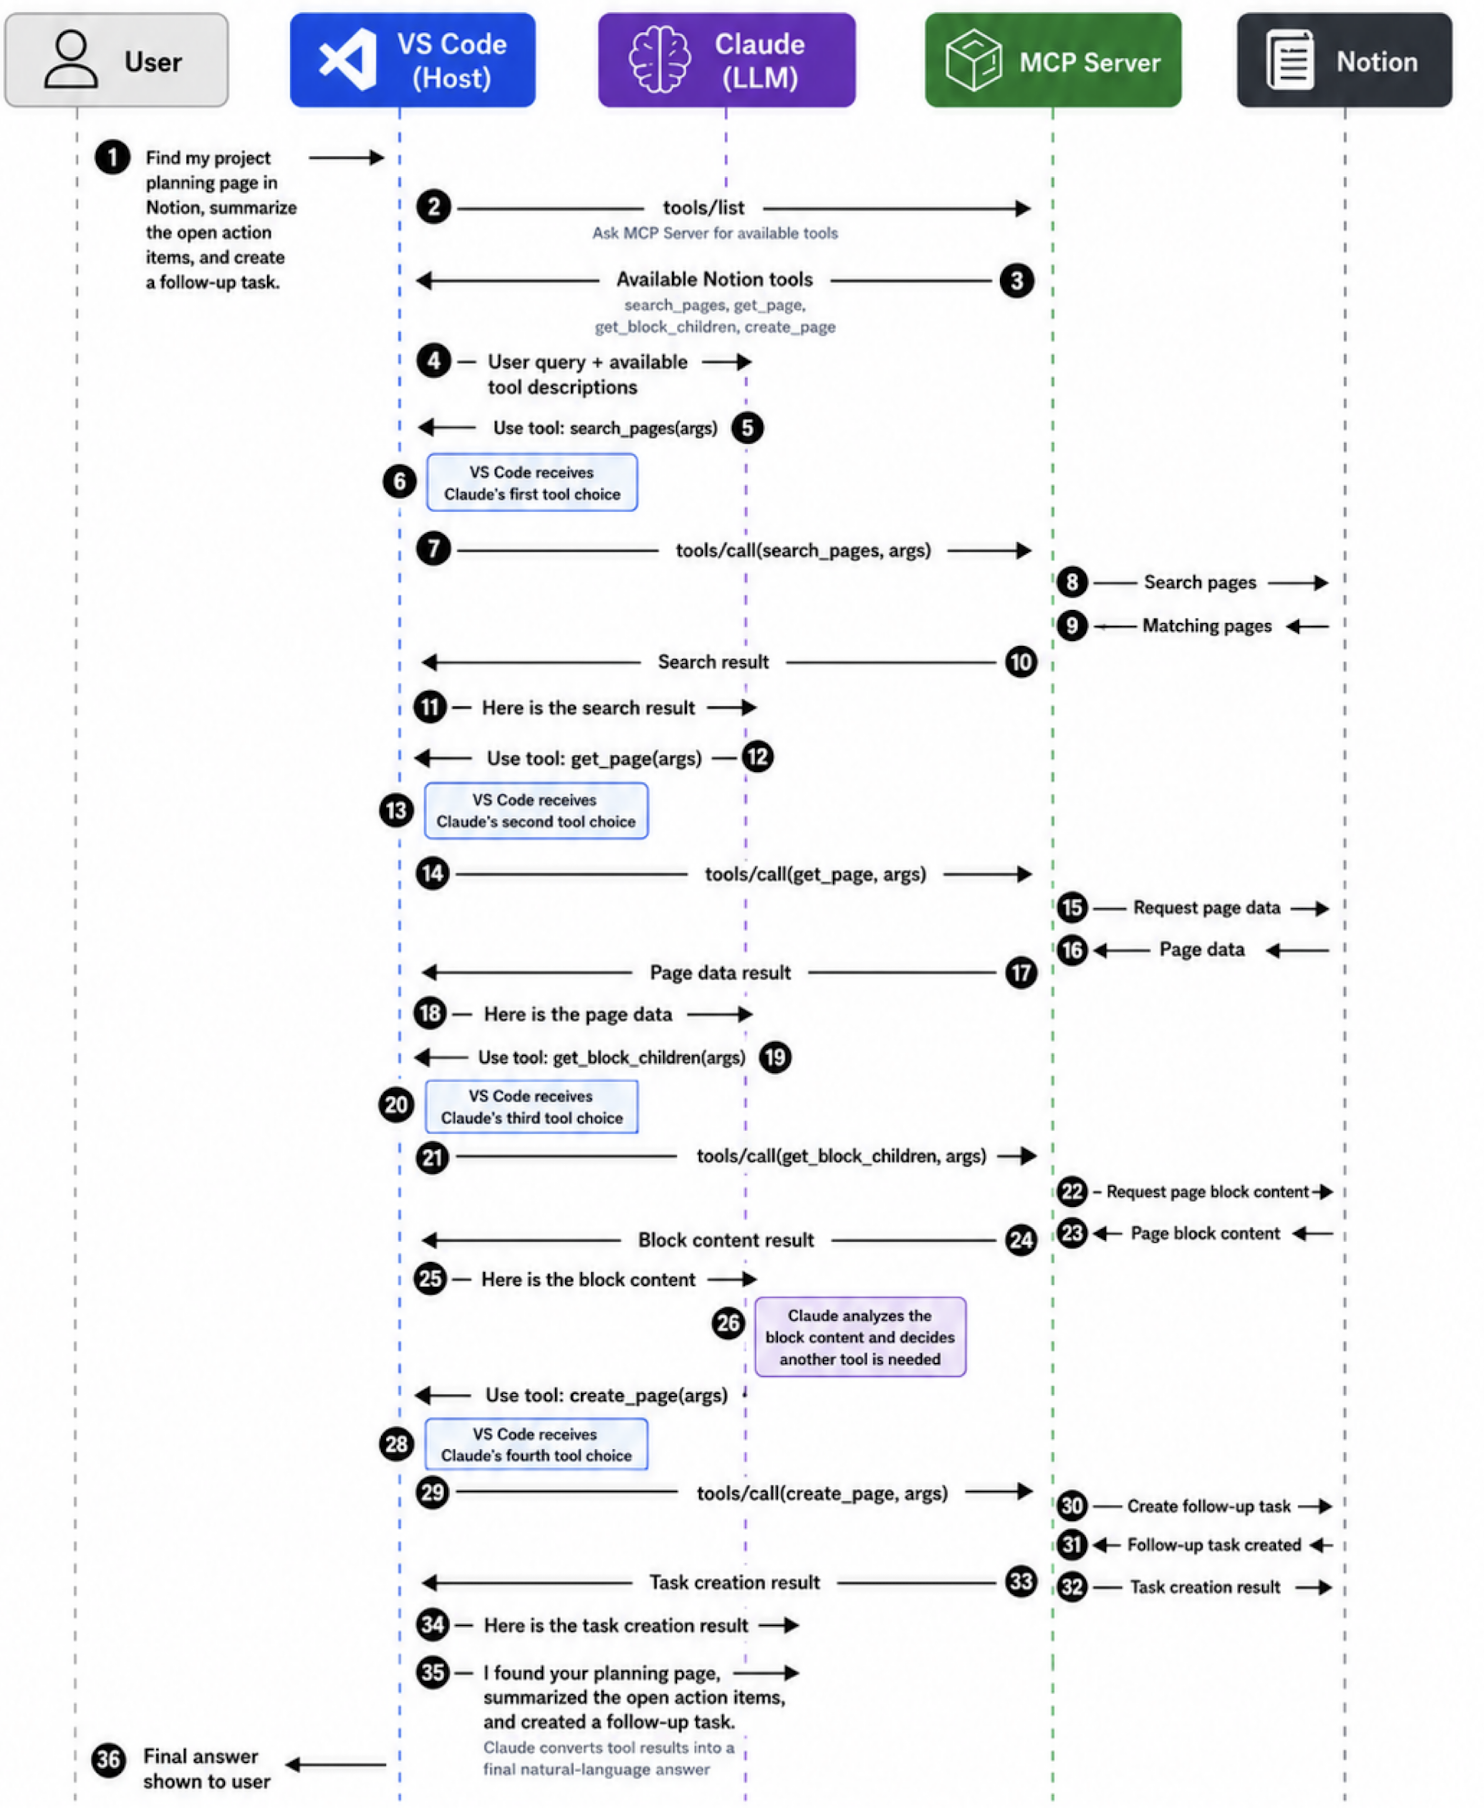